# Riproviamoci!! Cambiamo tecnica

In [1]:
import torch
from torch import nn
from torch import optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
import plotly.graph_objects as go
import numpy as np
import os
import csv
from pathlib import Path

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
def generate_sphere(num_points, radius=1.0, add_noise=False, noise_std=0.05, device='cpu'):
    """
    Genera punti su una sfera 3D partendo da coordinate angolari.
    """
    # 1. Campionamento uniforme sulla sfera
    # phi (azimut) in [0, 2pi)
    phi = torch.rand(num_points, device=device) * 2 * math.pi
    
    # cos(theta) in [-1, 1] per evitare l'addensamento ai poli
    costheta = (torch.rand(num_points, device=device) * 2*0.97) - 1
    theta = torch.acos(costheta)
    
    # 2. Trasformazione in coordinate cartesiane
    x = radius * torch.sin(theta) * torch.cos(phi)
    y = radius * torch.sin(theta) * torch.sin(phi)
    z = radius * torch.cos(theta)
    
    # 3. tensori 
    angles = torch.stack((theta, phi), dim=1)
    
    cartesian = torch.stack((x, y, z), dim=1)
    
    # Aggiunta opzionale di rumore Gaussiano alle coordinate spaziali, alla fine non l'ho usato
    if add_noise:
        cartesian += torch.randn_like(cartesian) * noise_std
        
    return angles, cartesian

# Generazione di 10.000 punti
N_POINTS = 10000
X_angles, Y_cartesian = generate_sphere(N_POINTS, radius=1.0, device=device)

print(f"Shape tensore angoli (Input): {X_angles.shape}")
print(f"Shape tensore cartesiano (Target): {Y_cartesian.shape}")

Shape tensore angoli (Input): torch.Size([10000, 2])
Shape tensore cartesiano (Target): torch.Size([10000, 3])


In [4]:
N_points = 10000
X_angles, Y_cartesian = generate_sphere(N_points, radius=1.0)

print(f"Shape tensore angoli (Input): {X_angles.shape}")
print(f"Shape tensore cartesiano (Target): {Y_cartesian.shape}")

Shape tensore angoli (Input): torch.Size([10000, 2])
Shape tensore cartesiano (Target): torch.Size([10000, 3])


(nota che possiamo anche vedere come va al variare del batch size!!)

In [5]:
batch_size = 100 #ha senso usare così tanti minibatches? sono tanti? 
dataset = torch.utils.data.TensorDataset(Y_cartesian, X_angles)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [int(0.8 * len(dataset)), int(0.2 * len(dataset))])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False, drop_last=True)

# training

In [86]:
in_dim = 3
out_dim = 2
hidden_dim = 100
#idea per ora: gli hidden layer li faccio con la stessa dim dell'output
#forse così impara una f.ne non lineare di 2 variabili(vediamo)
class Autoencoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), #0
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), #1
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim), #2
            #nn.Tanh(), tenere questo è fondamentalmente sbagliato!! perché tanh comprime tutto tra -1 e 1
            #mentre io voglio delle coordinate in R^2!!!
        )
        self.decoder = nn.Sequential(
            nn.Linear(out_dim, hidden_dim), #0
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), #1
            nn.Tanh(),
            nn.Linear(hidden_dim, in_dim), #2 #voglio la act. fn dopo questo layer? NO
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model_2 = Autoencoder(in_dim, hidden_dim, out_dim).to(device)

In [ ]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_2.parameters(), lr=1.e-3)

In [88]:
num_epochs = 100
model_2.train()
for epoch in range(num_epochs):

    loss_epoch = 0.0

    for x, _ in train_loader:

        x = x.to(device) #in teoria le y non servono no?

        x_pred = model_2(x)
        loss = loss_fn(x_pred, x)
        #train 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item() #item() per prendere il valore scalare dal tensore
    if(epoch % 5 == 0):
        print(f"Epoch {epoch}, Loss: {loss_epoch / len(train_loader):.6f}")


Epoch 0, Loss: 0.150356
Epoch 5, Loss: 0.017180
Epoch 10, Loss: 0.003396
Epoch 15, Loss: 0.001513
Epoch 20, Loss: 0.001176
Epoch 25, Loss: 0.000950
Epoch 30, Loss: 0.000850
Epoch 35, Loss: 0.000712
Epoch 40, Loss: 0.000619
Epoch 45, Loss: 0.000551
Epoch 50, Loss: 0.000444
Epoch 55, Loss: 0.000421
Epoch 60, Loss: 0.000367
Epoch 65, Loss: 0.000296
Epoch 70, Loss: 0.000303
Epoch 75, Loss: 0.000229
Epoch 80, Loss: 0.000191
Epoch 85, Loss: 0.000190
Epoch 90, Loss: 0.000185
Epoch 95, Loss: 0.000153


In [89]:
model_2.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        x_pred = model_2(x)
        loss = loss_fn(x_pred, x)
        print(f"Test Loss: {loss.item():.6f}")

Test Loss: 0.000280


In [90]:
nome_file = 'test_losses.csv'
data_dir = 'data'
file_esiste = os.path.isfile(data_dir + '/' + nome_file)

# Apriamo il file in modalità 'a' (append) per aggiungere righe senza sovrascrivere
with open(data_dir + '/' + nome_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    
    # Scrivi l'intestazione delle colonne solo se il file non esisteva
    if not file_esiste:
        writer.writerow(['Tanh', 'LeakyReLU', 'Sigmoid'])  # Intestazione delle colonne
        
    # Salviamo i numeri sulla stessa riga (uno a fianco all'altro)
    writer.writerow([loss.item(), '', ''])  

print(f"Risultati salvati con successo in {nome_file}!")

Risultati salvati con successo in test_losses.csv!


In [91]:
model_2.eval()
encoder = model_2.encoder
decoder = model_2.decoder

# 2. Calcoliamo i confini effettivi dello spazio latente per sapere dove creare la griglia
with torch.no_grad():
    latents = encoder(Y_cartesian.to(device)).cpu().numpy()

z1_min, z1_max = latents[:, 0].min(), latents[:, 0].max()
z2_min, z2_max = latents[:, 1].min(), latents[:, 1].max()

# 3. Definiamo la densità della griglia (quanti "assi" vogliamo)
num_lines = 15       # Numero di linee per ogni asse coordinato
pts_per_line = 100   # Risoluzione di ogni linea per renderla fluida nel 3D

z1_values = np.linspace(z1_min, z1_max, num_lines)
z2_values = np.linspace(z2_min, z2_max, num_lines)

# 4. Inizializziamo la figura Plotly
fig = go.Figure()

# Nota: Mettiamo i punti originali grigi e trasparenti sullo sfondo per dare un riferimento visivo
x_orig = Y_cartesian[:, 0].cpu().numpy()
y_orig = Y_cartesian[:, 1].cpu().numpy()
z_orig = Y_cartesian[:, 2].cpu().numpy()

fig.add_trace(go.Scatter3d(
    x=x_orig, y=y_orig, z=z_orig,
    mode='markers',
    marker=dict(size=1.5, color='lightgray', opacity=0.3),
    name='Sfera di Riferimento'
))

# 5. Generiamo e decodifichiamo le linee degli assi latenti
with torch.no_grad():
    
    # --- ASSE 1: Linee a Z1 costante (varia Z2) -> Colore BLU ---
    for z1 in z1_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = z1
        line_2d[:, 1] = np.linspace(z2_min, z2_max, pts_per_line)
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(0, 0, 255, 0.7)', width=4),
            showlegend=False
        ))

    # --- ASSE 2: Linee a Z2 costante (varia Z1) -> Colore ROSSO ---
    for z2 in z2_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = np.linspace(z1_min, z1_max, pts_per_line)
        line_2d[:, 1] = z2
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(255, 0, 0, 0.7)', width=4), 
            showlegend=False
        ))

# 6. Configurazione finale del Layout per visualizzare una sfera perfetta
fig.update_layout(
    title="Autoencoder Axis on the Sphere",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube' # Fondamentale per non distorcere la sfera in un uovo
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)
config = {
  'toImageButtonOptions': {
    'format': 'png', # Formati supportati: png, svg, jpeg, webp
    'filename': 'GrigliaAutoencoder_tanh',
    'height': 1080,
    'width': 1920,
    'scale': 3 # È il trucco magico: moltiplica la risoluzione di base!
  }
}

# Mostra la figura passando la configurazione
fig.show(config=config)

# che coordinate sono?

# stereo?

In [35]:
def coord_stereografiche(x):
    # x è un tensore di forma (N, 3) con coordinate cartesiane (x, y, z)
    x_cart = x[:, 0]
    y_cart = x[:, 1]
    z_cart = x[:, 2]
  
    denominator = 1 - z_cart + 1.e-10
    u = x_cart / denominator
    v = y_cart / denominator
    
    return torch.stack((u, v), dim=1)

In [36]:
def stereo_inv(z):
    u = z[:, 0]
    v = z[:, 1]
    denominator = 1 + u**2 + v**2
    x = 2 * u / denominator
    y = 2 * v / denominator
    z_cart = (denominator - 2) / denominator
    return torch.stack((x, y, z_cart), dim=1)

In [37]:
#mi serviva solo perché ho tolto tanh e ho reinizializzato il modello, così posso caricare i pesi salvati senza problemi
#ATTENZIONE NON HA SENSO FARE QUESTA COSA PERCHE' NON POSSO LOADARE PESI DI UN MODELLO CON ARCHITETTURA DIVERSA DA QUELLA SALVATA, 
# CIOE' RIPIGLIATI! ZERO SENSO
# model_2 = Autoencoder(in_dim, hidden_dim, out_dim).to(device)
# model_2.load_state_dict(torch.load(f="models/Sphere_autoencoder_tanh.pth", map_location=device))

In [92]:
with torch.no_grad():
    z = model_2.encoder(Y_cartesian.to(device)).detach() #dati encodati

In [69]:
dataset_1 = torch.utils.data.TensorDataset(Y_cartesian, z)
train_dataset_1, test_dataset_1 = torch.utils.data.random_split(dataset_1, [int(0.8 * len(dataset_1)), int(0.2 * len(dataset_1))])
train_loader_1 = torch.utils.data.DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_1 = torch.utils.data.DataLoader(test_dataset_1, batch_size=len(test_dataset_1), shuffle=False, drop_last=True)

In [70]:
class StereographicProjection(nn.Module):
    def __init__(self):
        super().__init__() 
       
        self.lin_corr = nn.Linear(2, 2)

    def forward(self, x):
       
        stereo = coord_stereografiche(x)
        z_hopefully = self.lin_corr(stereo)

        return z_hopefully
stereo_model = StereographicProjection().to(device)

In [71]:
loss_fn = nn.MSELoss()
optimizer_0 = optim.Adam(stereo_model.parameters(), lr=1e-2, weight_decay=1e-6)

In [72]:
epochs = 25

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    sum_loss = 0.0
    for x, y in train_loader_1:
        x = x.to(device)
        y = y.to(device)
        stereo_model.train()
        y_pred = stereo_model(x)
        loss = loss_fn(y_pred, y)
        sum_loss += loss.item()
        optimizer_0.zero_grad()
        loss.backward()
        optimizer_0.step()

    avg_loss = sum_loss / len(train_loader_1)
    with torch.no_grad(): 
      stereo_model.eval()
      for x, y in test_loader_1:
        test_features = x.to(device)
        test_labels = y.to(device)
      test_pred = stereo_model(test_features)
      test_loss = loss_fn(test_pred, test_labels)
      epoch_count.append(epoch)
      train_loss_values.append(avg_loss)
      test_loss_values.append(test_loss.detach().cpu().numpy())
      if (epoch) % 5 == 0:
         print(f"Epoch: {epoch} | MSE Train Loss: {avg_loss} | MSE Test Loss: {test_loss} ")

Epoch: 0 | MSE Train Loss: 1.0537916276603938 | MSE Test Loss: 0.325161874294281 
Epoch: 5 | MSE Train Loss: 0.06316520986147225 | MSE Test Loss: 0.06383790075778961 
Epoch: 10 | MSE Train Loss: 0.06331232464872301 | MSE Test Loss: 0.0641874149441719 
Epoch: 15 | MSE Train Loss: 0.06348811741918325 | MSE Test Loss: 0.06434116512537003 
Epoch: 20 | MSE Train Loss: 0.06348712067119777 | MSE Test Loss: 0.06414246559143066 


In [93]:
y_stereo = coord_stereografiche(Y_cartesian.to(device)).detach() #dati stereografici

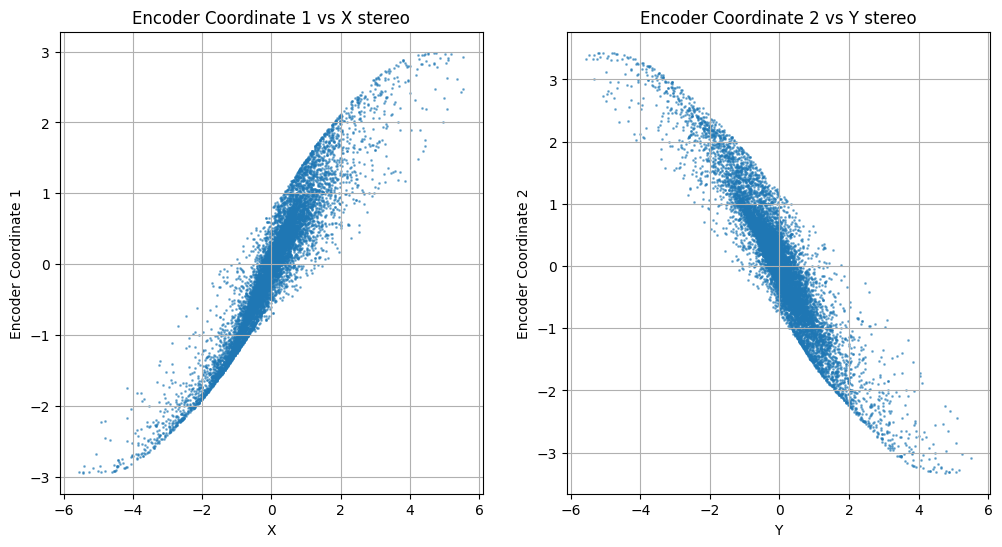

In [94]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Encoder Coordinate 1 vs X stereo")
plt.xlabel("X")
plt.ylabel("Encoder Coordinate 1")
plt.scatter(y_stereo[:, 0].cpu(), z[:, 1].cpu(), s=1, alpha=0.5) 
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Encoder Coordinate 2 vs Y stereo")
plt.xlabel("Y")
plt.ylabel("Encoder Coordinate 2")
plt.scatter(y_stereo[:, 1].cpu(), z[:, 0].cpu(), s=1, alpha=0.5)
plt.grid()

In [95]:
X_stereo = torch.stack((y_stereo[:, 0], z[:, 1]), dim=1)
Y_stereo = torch.stack((y_stereo[:, 1], z[:, 0]), dim=1)
R_x = torch.corrcoef(X_stereo.T.cpu())
R_y = torch.corrcoef(Y_stereo.T.cpu())
print("Correlation between Encoder Coordinate 1 and X stereo:", R_x[0, 1].item())
print("Correlation between Encoder Coordinate 2 and Y stereo:", R_y[0, 1].item())


Correlation between Encoder Coordinate 1 and X stereo: 0.9385657906532288
Correlation between Encoder Coordinate 2 and Y stereo: -0.926811933517456


In [96]:
#salvo i coefficienti di pearson in un csv così ci lavoro poi sopra hopefully(?)
numero_1 = R_x[0, 1].item()
numero_2 = R_y[0, 1].item()

nome_file = 'NEWpearson_encoderVsStereo_tanh.csv'
data_dir = 'data'
file_esiste = os.path.isfile(data_dir + '/' + nome_file)

# Apriamo il file in modalità 'a' (append) per aggiungere righe senza sovrascrivere
with open(data_dir + '/' + nome_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    
    # Scriviamo l'intestazione delle colonne solo se il file non esisteva
    if not file_esiste:
        writer.writerow(['Valore_1', 'Valore_2'])
        
    # Salviamo i due numeri sulla stessa riga (uno a fianco all'altro)
    writer.writerow([numero_1, numero_2])

print(f"Risultati salvati con successo in {nome_file}!")

Risultati salvati con successo in NEWpearson_encoderVsStereo_tanh.csv!


# salviamo i modelli

In [40]:
MODEL_PATH = Path("models")
#MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "NEWSphere_autoencoder_tanh.pth" #attenzione ho sbagliato e ho salvato una sigmoid, uffa
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\NEWSphere_autoencoder_tanh.pth


In [315]:
NOME = "NEWstereo_model_tanh.pth"
NOME_DIR = Path("models")
PATH = NOME_DIR / NOME
torch.save(obj = stereo_model.state_dict(), 
           f=PATH)

tutto salvato, perfect, volendo se vuoi recuperarli leggi sotto

In [46]:
loaded_model = Autoencoder(in_dim, hidden_dim, out_dim).to(device)
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model.load_state_dict(torch.load(f="models/NEWSphere_autoencoder_tanh.pth"))
loaded_stereo = StereographicProjection().to(device)
loaded_stereo.load_state_dict(torch.load(f="models/NEWstereo_model_tanh.pth"))

<All keys matched successfully>

# cosa viene ricostruito di meno?

In [63]:
model_2.eval()
encoder = model_2.encoder
decoder = model_2.decoder

# 2. Calcoliamo i confini effettivi dello spazio latente per sapere dove creare la griglia
with torch.no_grad():
    latents = encoder(Y_cartesian.to(device)).cpu().numpy()

z1_min, z1_max = latents[:, 0].min(), latents[:, 0].max()
z2_min, z2_max = latents[:, 1].min(), latents[:, 1].max()

# 3. Definiamo la densità della griglia (quanti "assi" vogliamo)
num_lines = 15       # Numero di linee per ogni asse coordinato
pts_per_line = 100   # Risoluzione di ogni linea per renderla fluida nel 3D

z1_values = np.linspace(z1_min, z1_max, num_lines)
z2_values = np.linspace(z2_min, z2_max, num_lines)

# 4. Inizializziamo la figura Plotly
fig = go.Figure()

# 1. First, calculate errors for individual points
model_2.eval()
all_points = []
all_errors = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        x_pred = model_2(x)
        
        # Calculate Euclidean distance (error) PER POINT, not per batch
        # dim=1 means it calculates the distance across the x,y,z coordinates
        point_errors = torch.norm(x - x_pred, dim=1) 
        
        all_points.append(x.cpu())
        all_errors.append(point_errors.cpu())

# Combine all batches into single arrays
points_np = torch.cat(all_points).numpy()
errors_np = torch.cat(all_errors).numpy()
#v_max = np.percentile(errors_np, 99.95)
fig.add_trace(go.Scatter3d(
    x=points_np[:, 0], 
    y=points_np[:, 1], 
    z=points_np[:, 2],
    mode='markers',
    marker=dict(
        size=6, 
        color=errors_np,         # Color points based on their individual error
        colorscale='viridis_r',     #(r = reverse) 'plasma' or 'inferno' are great for highlighting high values
        cmin=0,                  # Forza il minimo a 0
        #cmax=v_max,
        opacity=1,
        colorbar=dict(title="Absolute Reconstruction Error", x=-0.1) # Move colorbar to the left
    ),
    name='distance from original points of the reconstructed points'
))

# 5. Generiamo e decodifichiamo le linee degli assi latenti
with torch.no_grad():
    
    # --- ASSE 1: Linee a Z1 costante (varia Z2) -> Colore BLU ---
    for z1 in z1_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = z1
        line_2d[:, 1] = np.linspace(z2_min, z2_max, pts_per_line)
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='blue', width=2.5),
            showlegend=False
        ))

    # --- ASSE 2: Linee a Z2 costante (varia Z1) -> Colore ROSSO ---
    for z2 in z2_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = np.linspace(z1_min, z1_max, pts_per_line)
        line_2d[:, 1] = z2
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='red', width=2.5), 
            showlegend=False
        ))
num_lines_1 = 30       # Numero di linee per ogni asse coordinato
pts_per_line = 100   # Risoluzione di ogni linea per renderla fluida nel 3D


#-----------------------------------------------------------------------------------------------
# 6. Configurazione finale del Layout per visualizzare una sfera perfetta
fig.update_layout(
    title="Reconstruction Error heatmap",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube' # Fondamentale per non distorcere la sfera in un uovo
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)
config = {
  'toImageButtonOptions': {
    'format': 'png', # Formati supportati: png, svg, jpeg, webp
    'filename': 'reconstruction_error_heatmap_tanh_',
    'height': 1000,
    'width': 1400,
    # 'scale': 7 # È il trucco magico: moltiplica la risoluzione di base!
  }
}
# #Mostra la figura passando la configurazione
fig.show(config=config)
#fig.show()